# Fase 2 — Análisis Exploratorio de Datos (EDA)

**Proyecto:** Análisis de Ventas 2020-2023 — Prueba Técnica Summan
**Autor:** Sebastian Lesmes | **Fecha:** Abril 2026

---

### Estructura del análisis
| Bloque | Contenido |
|---|---|
| 2.1 | Calidad post-carga e integridad referencial |
| 2.2 | Análisis univariado (distribuciones individuales) |
| 2.3 | Análisis bivariado (relaciones entre variables — clave para ML) |
| 2.4 | Análisis temporal (tendencias 2020-2023) |
| 2.5 | Detección de outliers |
| 2.6 | Hallazgos consolidados y recomendaciones |

> **Fuente:** Todos los datos se consultan desde `sales_db` en MariaDB


## 0. Setup

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from dotenv import load_dotenv
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Estilo visual uniforme
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

# Conexión MariaDB
from sqlalchemy import create_engine, text


load_dotenv()  # Carga variables de entorno desde .env
DB_USER = os.getenv('DB_USER')
DB_PASS = os.getenv('DB_PASS')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/sales_db", echo=False)

def query(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

print("Conexion a sales_db establecida")


Conexion a sales_db establecida


## Bloque 2.1 — Calidad post-carga e integridad referencial

Verificar que la carga fue correcta y que las llaves foráneas son consistentes.

In [29]:
# Conteo de registros por tabla
tablas = ['fact_sales', 'dim_customer', 'dim_product', 'dim_regional_manager', 'dim_returns']
print("Registros por tabla en sales_db:")
print("-" * 40)
for t in tablas:
    n = query(f"SELECT COUNT(*) AS n FROM {t}").iloc[0]['n']
    print(f"  {t:<30}: {n:>6,}")


Registros por tabla en sales_db:
----------------------------------------
  fact_sales                    : 10,187
  dim_customer                  :    804
  dim_product                   :  1,894
  dim_regional_manager          :      4
  dim_returns                   :    296


In [30]:
# Integridad referencial: Customer_ID
q_cust = '''
SELECT COUNT(DISTINCT fs.Customer_ID) AS en_ventas,
       COUNT(DISTINCT dc.Customer_ID) AS en_dimension,
       SUM(CASE WHEN dc.Customer_ID IS NULL THEN 1 ELSE 0 END) AS huerfanos
FROM fact_sales fs
LEFT JOIN dim_customer dc ON fs.Customer_ID = dc.Customer_ID
'''
print("Customer_ID:")
print(query(q_cust).to_string(index=False))

# Integridad referencial: Product_ID
q_prod = '''
SELECT COUNT(DISTINCT fs.Product_ID) AS en_ventas,
       COUNT(DISTINCT dp.Product_ID) AS en_dimension,
       SUM(CASE WHEN dp.Product_ID IS NULL THEN 1 ELSE 0 END) AS huerfanos
FROM fact_sales fs
LEFT JOIN dim_product dp ON fs.Product_ID = dp.Product_ID
'''
print("\nProduct_ID:")
print(query(q_prod).to_string(index=False))

# Órdenes devueltas que existen en fact_sales
q_ret = '''
SELECT COUNT(DISTINCT dr.Order_ID) AS ordenes_devueltas,
       SUM(CASE WHEN fs.Order_ID IS NULL THEN 1 ELSE 0 END) AS sin_match
FROM dim_returns dr
LEFT JOIN fact_sales fs ON dr.Order_ID = fs.Order_ID
'''
print("\nReturns vs fact_sales:")
print(query(q_ret).to_string(index=False))


Customer_ID:
 en_ventas  en_dimension  huerfanos
       804           804     0.0000

Product_ID:
 en_ventas  en_dimension  huerfanos
      1862          1862     0.0000

Returns vs fact_sales:
 ordenes_devueltas  sin_match
               296     0.0000


## Bloque 2.2 — Análisis univariado

Distribuciones individuales de las variables numéricas y categóricas principales.

In [31]:
# Cargar tablas completas para análisis Python
df_sales = query("SELECT * FROM fact_sales")
df_customer = query("SELECT * FROM dim_customer")
df_product  = query("SELECT * FROM dim_product")
df_manager  = query("SELECT * FROM dim_regional_manager")
df_returns  = query("SELECT * FROM dim_returns")

# JOIN principal: ventas + producto + cliente (tabla de trabajo del EDA)
df = query('''
    SELECT
        fs.*,
        dp.Category, dp.`Sub-Category`, dp.Product_Name,
        dc.monthly_salary, dc.age, dc.marital_status, dc.credit_score,
        dm.Regional_Manager,
        CASE WHEN dr.Order_ID IS NOT NULL THEN 1 ELSE 0 END AS is_returned
    FROM fact_sales fs
    LEFT JOIN dim_product     dp ON fs.Product_ID   = dp.Product_ID
    LEFT JOIN dim_customer    dc ON fs.Customer_ID  = dc.Customer_ID
    LEFT JOIN dim_regional_manager dm ON fs.Region  = dm.Region
    LEFT JOIN dim_returns     dr ON fs.Order_ID     = dr.Order_ID
''')

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'])
df['year']       = df['Order_Date'].dt.year
df['month']      = df['Order_Date'].dt.month
df['month_name'] = df['Order_Date'].dt.strftime('%b')

print(f"Tabla de trabajo: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print("Columnas:", list(df.columns))


Tabla de trabajo: 10,529 filas x 28 columnas
Columnas: ['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Country/Region', 'City', 'State/Province', 'Postal_Code', 'Region', 'Product_ID', 'Sales', 'Quantity', 'Discount', 'Profit', 'Category', 'Sub-Category', 'Product_Name', 'monthly_salary', 'age', 'marital_status', 'credit_score', 'Regional_Manager', 'is_returned', 'year', 'month', 'month_name']


In [32]:
# Busqueda del percentil optimo para Sales
# Metodo: winsorizar (clip) al percentil p y medir desviacion mean/median
# Criterio: encontrar el percentil MAS ALTO donde desviacion <= 15%
# (mas alto = mas datos incluidos sin distorsion en la media)

original_mean   = df['Sales'].mean()
original_median = df['Sales'].median()
print(f'Sales sin recorte -> mean: ${original_mean:,.2f} | median: ${original_median:,.2f} | desv: {(original_mean/original_median-1)*100:.1f}%')
print()
print(f'{"Percentil":>10} {"Cap ($)":>10} {"Mean clip":>11} {"Median clip":>12} {"Desv%":>8}')
print('-' * 58)

resultados = {}
for p in range(50, 100):
    cap = df['Sales'].quantile(p / 100)
    clipped = df['Sales'].clip(upper=cap)
    s_mean, s_med = clipped.mean(), clipped.median()
    s_dev = (s_mean / s_med - 1) * 100
    resultados[p] = dict(cap=cap, s_mean=s_mean, s_med=s_med, s_dev=s_dev)
    if p >= 70:
        marker = ' <--' if s_dev <= 15 else ''
        print(f'p{p:<9} {cap:>10,.0f} {s_mean:>11,.2f} {s_med:>12,.2f} {s_dev:>7.1f}%{marker}')

# Percentil optimo: el mas alto donde desviacion <= 15%
TARGET = 15.0
P_OPT  = 70
for p in range(99, 69, -1):
    if resultados[p]['s_dev'] <= TARGET:
        P_OPT = p
        break

r = resultados[P_OPT]
CAP_SALES = r['cap']

print(f'\nPercentil optimo seleccionado : p{P_OPT}')
print(f'  Umbral Sales                 : ${CAP_SALES:,.2f}')
print(f'  Mean winsorizado             : ${r["s_mean"]:,.2f}')
print(f'  Median winsorizado           : ${r["s_med"]:,.2f}')
print(f'  Desviacion mean/median       : {r["s_dev"]:.1f}%')

# Separar en df_viz (principal) y df_premium usando el umbral hallado
df_viz     = df[df['Sales'] <= CAP_SALES].copy()
df_premium = df[df['Sales'] >  CAP_SALES].copy()

print(f'\ndf_viz     : {len(df_viz):,} registros  ({len(df_viz)/len(df)*100:.1f}%)  Sales <= ${CAP_SALES:,.2f}')
print(f'df_premium : {len(df_premium):,} registros  ({len(df_premium)/len(df)*100:.1f}%)  Sales >  ${CAP_SALES:,.2f}')
print('df original: preservado sin modificar.')

Impacto del percentil de corte en mean vs median (Sales)
 Percentil  % datos   Sales mean  Sales median   Desv%   Profit mean  Profit median   Desv%
-----------------------------------------------------------------------------------------------
p85           85.0%        79.63         38.48  107.0%          8.32           7.26   14.7%
p86           86.0%        83.40         39.66  110.3%          8.72           7.38   18.1%
p87           87.0%        87.49         39.98  118.8%          8.93           7.48   19.5%
p88           88.0%        91.88         40.74  125.5%          9.23           7.58   21.8%
p89           89.0%        96.48         41.85  130.5%          9.56           7.62   25.5%
p90           90.0%       101.56         42.89  136.8%         10.02           7.70   30.1%
p91           91.0%       107.07         43.92  143.8%         10.59           7.78   36.2%
p92           92.0%       112.91         45.00  150.9%         11.06           7.89   40.2%
p93           93.0%

In [33]:
# Estadisticas descriptivas — comparacion entre segmentos
cols_num = ['Sales', 'Profit', 'Discount', 'Quantity']

print('=== Dataset completo (incluye extremos) ===')
print(df[cols_num].describe().round(2).to_string())

print(f'\n=== df_viz — segmento principal (p{P_OPT} en Sales) ===')
print(df_viz[cols_num].describe().round(2).to_string())

print(f'\n=== df_premium — segmento extremo (Sales > umbral p{P_OPT}) ===')
print(df_premium[cols_num].describe().round(2).to_string())

print(f'\nNota: df_viz = {len(df_viz):,} registros ({len(df_viz)/len(df)*100:.1f}%)'
      f' | df_premium = {len(df_premium):,} registros ({len(df_premium)/len(df)*100:.1f}%)')

=== Dataset completo (incluye extremos) ===
           Sales     Profit   Discount   Quantity
count 10529.0000 10529.0000 10529.0000 10529.0000
mean    230.0500    29.0100     0.1600     3.7900
std     617.1000   230.0500     0.2100     2.2300
min       0.4400 -6599.9800     0.0000     1.0000
25%      17.4700     1.8000     0.0000     2.0000
50%      54.9900     8.7900     0.2000     3.0000
75%     210.3900    29.9500     0.2000     5.0000
max   22638.4800  8399.9800     0.8000    14.0000

=== df_viz — segmento principal (p85 en Sales) ===
          Sales    Profit  Discount  Quantity
count 8950.0000 8950.0000 8950.0000 8950.0000
mean    79.6300   10.2700    0.1600    3.5800
std     92.5400   41.6100    0.2100    2.1200
min      0.4400 -766.0100    0.0000    1.0000
25%     14.8800    1.7800    0.0000    2.0000
50%     38.4800    7.2600    0.1500    3.0000
75%    108.7800   20.1200    0.2000    5.0000
max    388.7000  182.3600    0.8000   14.0000

=== df_premium — segmento extremo (Sale

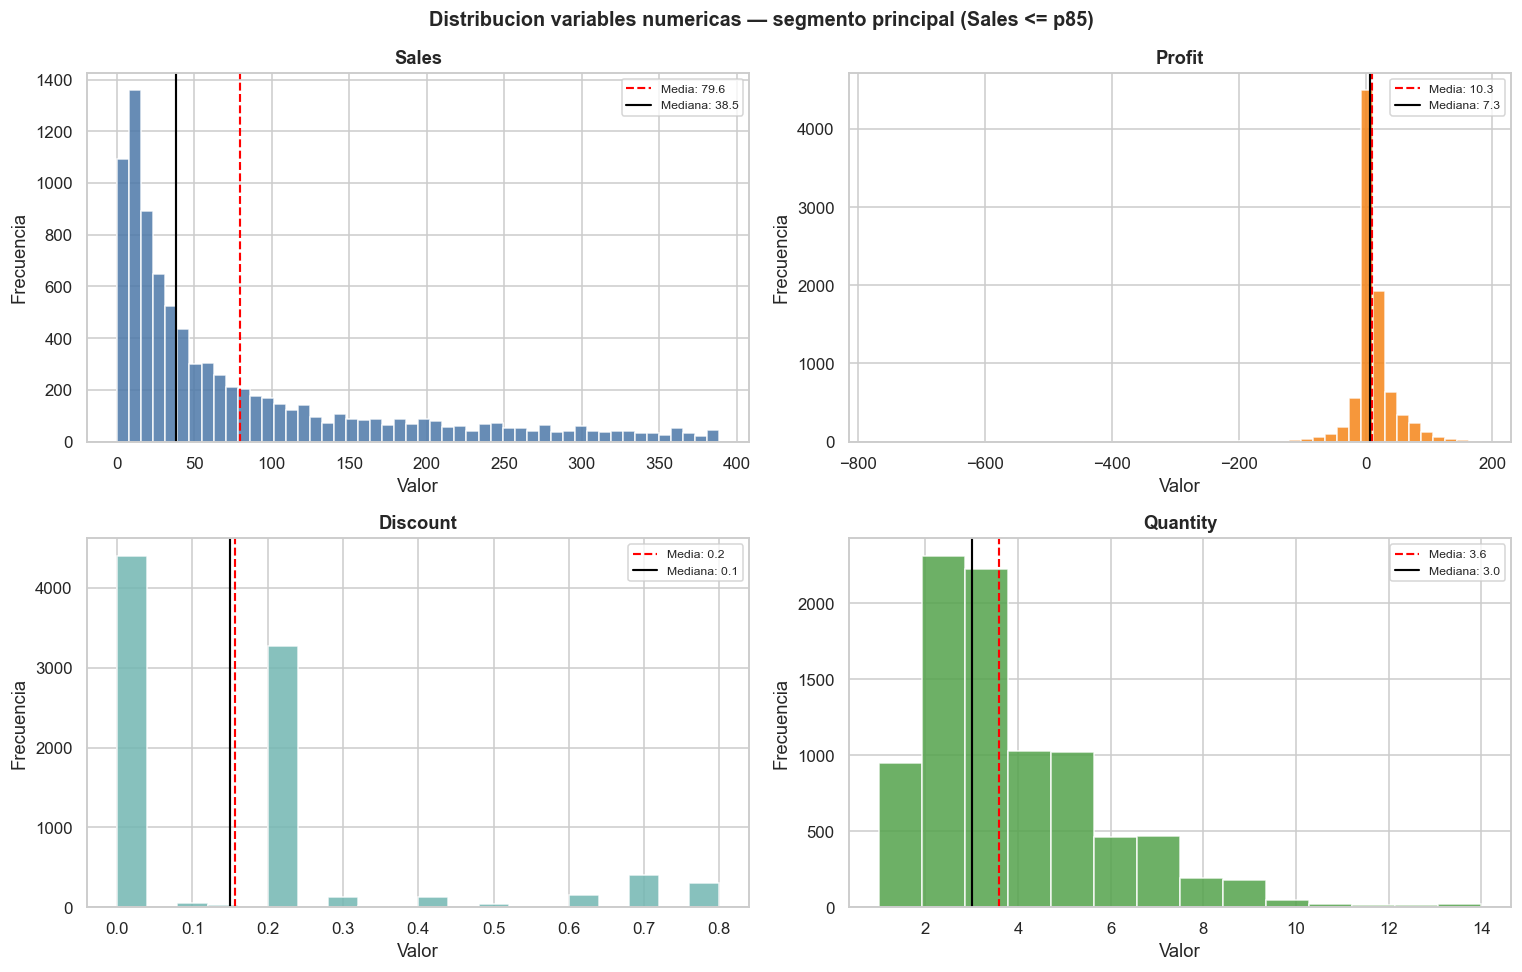

In [34]:
# Distribucion de variables numericas — segmento principal (df_viz)
# Sales y Profit: filas dentro del percentil optimo (sin extremos)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Distribucion variables numericas — segmento principal (Sales <= p{P_OPT})', fontsize=13, fontweight='bold')

configs = [
    ('Sales',    df_viz, axes[0,0], '#4C78A8', 50),
    ('Profit',   df_viz, axes[0,1], '#F58518', 50),
    ('Discount', df_viz, axes[1,0], '#72B7B2', 20),
    ('Quantity', df_viz, axes[1,1], '#54A24B', 14),
]

for col, source, ax, color, bins in configs:
    data = source[col].dropna()
    ax.hist(data, bins=bins, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.4, label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='black', linestyle='-',  linewidth=1.4, label=f'Mediana: {data.median():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/eda_02_distribucion.png', bbox_inches='tight')
plt.show()

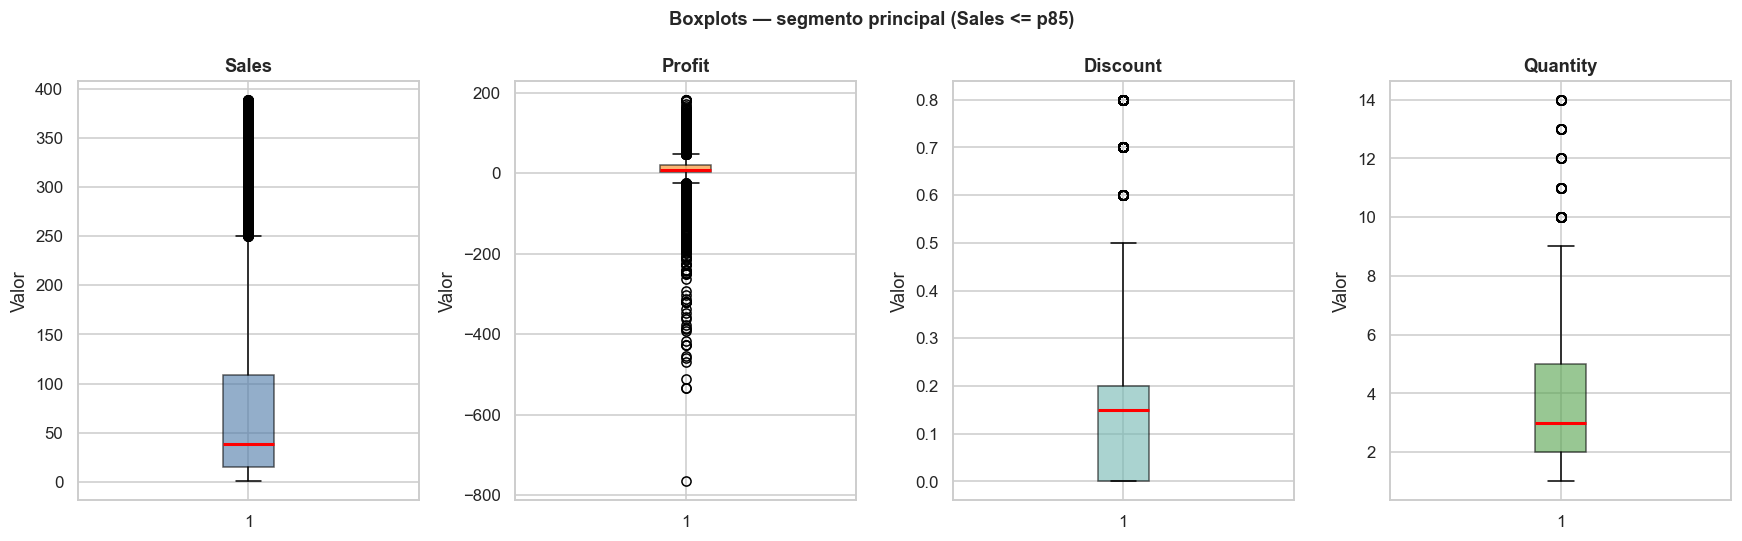

In [35]:
# Boxplots — segmento principal (df_viz, sin extremos premium)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle(f'Boxplots — segmento principal (Sales <= p{P_OPT})', fontsize=12, fontweight='bold')

for ax, col, color in zip(axes, ['Sales','Profit','Discount','Quantity'],
                          ['#4C78A8','#F58518','#72B7B2','#54A24B']):
    ax.boxplot(df_viz[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.savefig('../outputs/eda_03_boxplots.png', bbox_inches='tight')
plt.show()

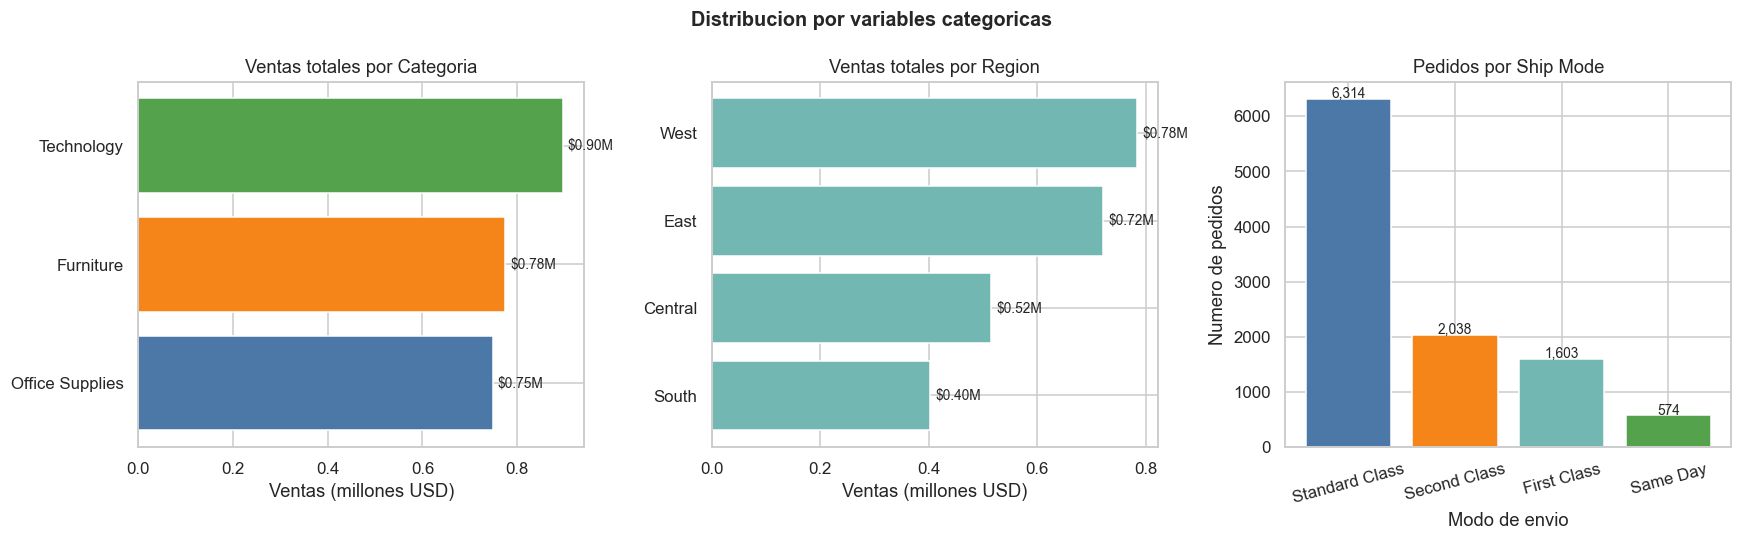

In [36]:
# ── Frecuencia por variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribucion por variables categoricas', fontsize=13, fontweight='bold')

# Categoría de producto
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
axes[0].barh(cat_sales.index, cat_sales.values / 1e6, color=['#4C78A8','#F58518','#54A24B'])
axes[0].set_title('Ventas totales por Categoria')
axes[0].set_xlabel('Ventas (millones USD)')
for i, v in enumerate(cat_sales.values / 1e6):
    axes[0].text(v + 0.01, i, f'${v:.2f}M', va='center', fontsize=9)

# Región
reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=True)
axes[1].barh(reg_sales.index, reg_sales.values / 1e6, color='#72B7B2')
axes[1].set_title('Ventas totales por Region')
axes[1].set_xlabel('Ventas (millones USD)')
for i, v in enumerate(reg_sales.values / 1e6):
    axes[1].text(v + 0.01, i, f'${v:.2f}M', va='center', fontsize=9)

# Ship Mode
ship_counts = df['Ship_Mode'].value_counts()
colors_ship = ['#4C78A8', '#F58518', '#72B7B2', '#54A24B']
axes[2].bar(ship_counts.index, ship_counts.values, color=colors_ship)
axes[2].set_title('Pedidos por Ship Mode')
axes[2].set_xlabel('Modo de envio')
axes[2].set_ylabel('Numero de pedidos')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(ship_counts.values):
    axes[2].text(i, v + 20, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/eda_03_categoricas.png', bbox_inches='tight')
plt.show()


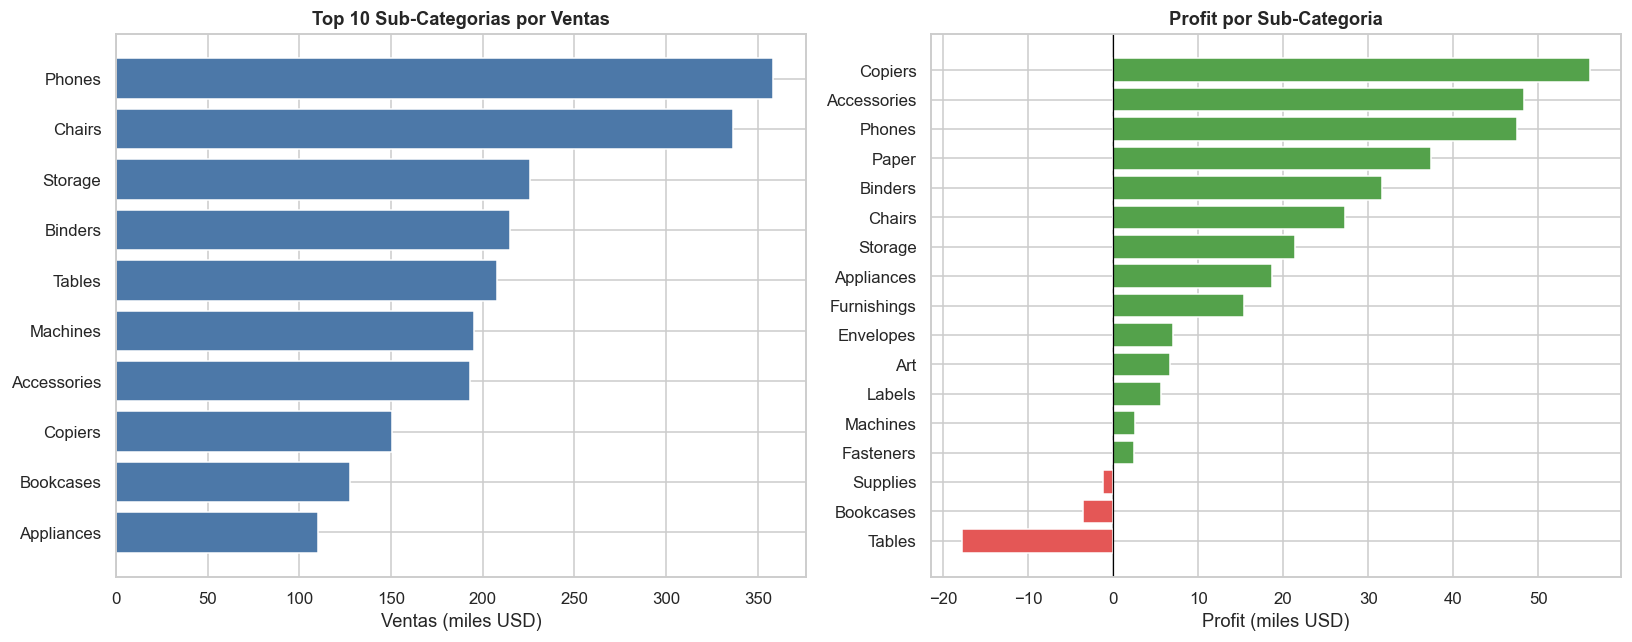

Sub-categorias con profit NEGATIVO:
  Tables              : $-17,753.21
  Bookcases           : $-3,589.26
  Supplies            : $-1,171.39


In [37]:
# ── Top 10 Sub-Categorías por ventas y por profit
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sub_sales = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).sort_values()
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors_pos = ['#54A24B' if v >= 0 else '#E45756' for v in sub_profit.values]

axes[0].barh(sub_sales.index, sub_sales.values / 1e3, color='#4C78A8')
axes[0].set_title('Top 10 Sub-Categorias por Ventas', fontweight='bold')
axes[0].set_xlabel('Ventas (miles USD)')

axes[1].barh(sub_profit.index, sub_profit.values / 1e3, color=colors_pos)
axes[1].set_title('Profit por Sub-Categoria', fontweight='bold')
axes[1].set_xlabel('Profit (miles USD)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../outputs/eda_04_subcategorias.png', bbox_inches='tight')
plt.show()

# Sub-categorías con profit negativo
neg = df.groupby('Sub-Category')['Profit'].sum()
neg_cats = neg[neg < 0].sort_values()
print("Sub-categorias con profit NEGATIVO:")
for cat, val in neg_cats.items():
    print(f"  {cat:<20}: ${val:,.2f}")


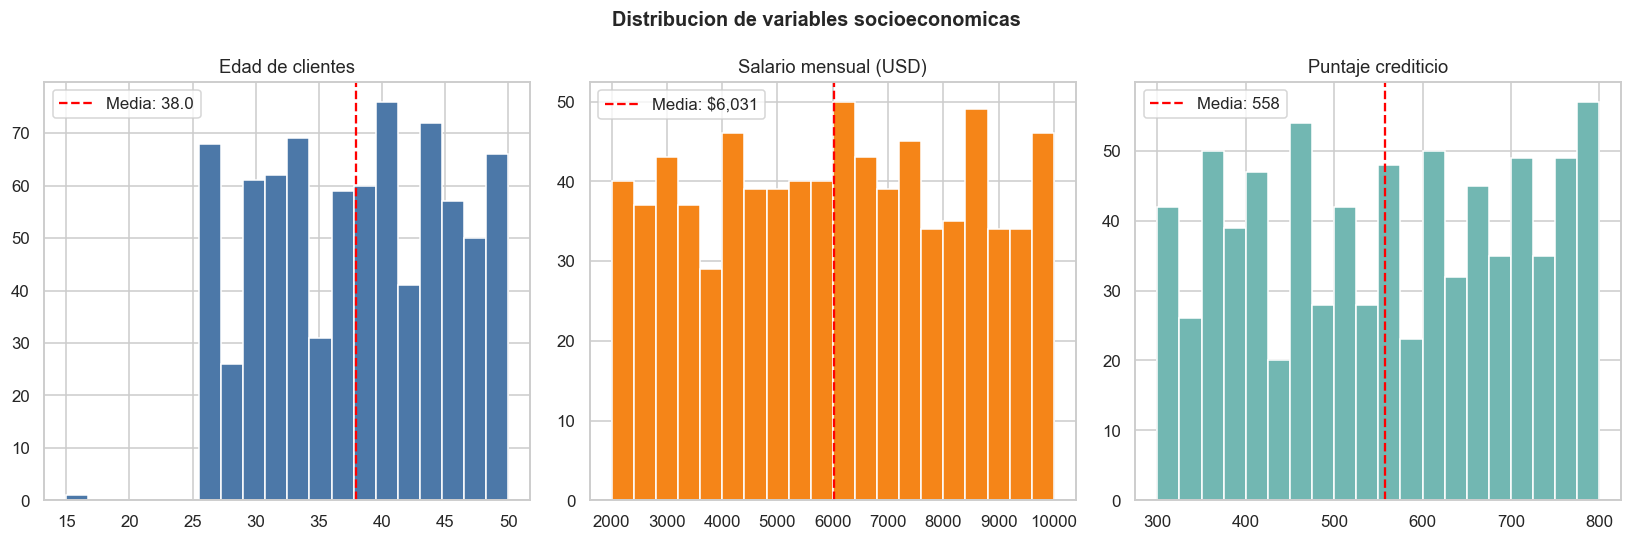

Clientes analizados: 799
Estado civil: {1.0: 413, 0.0: 386} (1=casado, 0=soltero)


In [38]:
# ── Variables socioeconómicas de Customer
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribucion de variables socioeconomicas', fontsize=13, fontweight='bold')

# Obtener una fila por cliente (evitar duplicados por transacciones)
df_cust_uniq = df.drop_duplicates(subset='Customer_ID')[['Customer_ID','age','monthly_salary','credit_score','marital_status']].dropna()

axes[0].hist(df_cust_uniq['age'], bins=20, color='#4C78A8', edgecolor='white')
axes[0].set_title('Edad de clientes')
axes[0].axvline(df_cust_uniq['age'].mean(), color='red', linestyle='--', label=f"Media: {df_cust_uniq['age'].mean():.1f}")
axes[0].legend()

axes[1].hist(df_cust_uniq['monthly_salary'], bins=20, color='#F58518', edgecolor='white')
axes[1].set_title('Salario mensual (USD)')
axes[1].axvline(df_cust_uniq['monthly_salary'].mean(), color='red', linestyle='--',
                label=f"Media: ${df_cust_uniq['monthly_salary'].mean():,.0f}")
axes[1].legend()

axes[2].hist(df_cust_uniq['credit_score'], bins=20, color='#72B7B2', edgecolor='white')
axes[2].set_title('Puntaje crediticio')
axes[2].axvline(df_cust_uniq['credit_score'].mean(), color='red', linestyle='--',
                label=f"Media: {df_cust_uniq['credit_score'].mean():.0f}")
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/eda_05_socioeconomicas.png', bbox_inches='tight')
plt.show()

print(f"Clientes analizados: {len(df_cust_uniq):,}")
print(f"Estado civil: {df_cust_uniq['marital_status'].value_counts().to_dict()} (1=casado, 0=soltero)")


## Bloque 2.3 — Análisis bivariado

### Hipótesis central a validar empíricamente
> **¿Existe una relación negativa entre nivel de descuento y rentabilidad?**

Este análisis es la base de justificación del modelo ML de la Fase 5.
No se asume causalidad — solo se explora la asociación estadística.


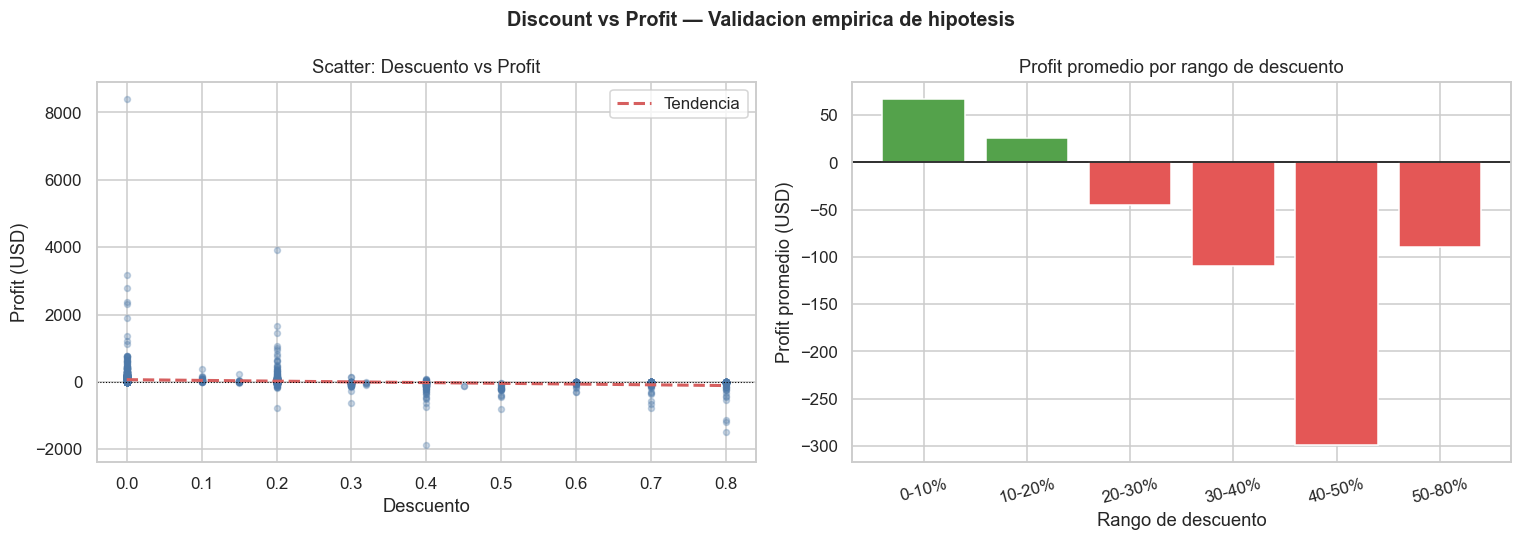

Correlacion de Pearson:
          Discount  Profit   Sales  Quantity
Discount    1.0000 -0.2228 -0.0274    0.0072
Profit     -0.2228  1.0000  0.4809    0.0673
Sales      -0.0274  0.4809  1.0000    0.2015
Quantity    0.0072  0.0673  0.2015    1.0000


In [39]:
# ── Correlación: Discount vs Profit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Discount vs Profit — Validacion empirica de hipotesis', fontsize=13, fontweight='bold')

# Scatter con regresión
sample = df.sample(min(3000, len(df)), random_state=42)
axes[0].scatter(sample['Discount'], sample['Profit'], alpha=0.3, s=15, color='#4C78A8')

# ✅ Drop NaNs together to keep arrays aligned
sample_clean = sample[['Discount', 'Profit']].dropna()
z = np.polyfit(sample_clean['Discount'], sample_clean['Profit'], 1)

p = np.poly1d(z)
x_line = np.linspace(0, sample['Discount'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Tendencia')
axes[0].axhline(0, color='black', linewidth=0.7, linestyle=':')
axes[0].set_xlabel('Descuento')
axes[0].set_ylabel('Profit (USD)')
axes[0].set_title('Scatter: Descuento vs Profit')
axes[0].legend()

# Profit medio por rango de descuento (bins)
df['discount_bin'] = pd.cut(df['Discount'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8],
                             labels=['0-10%','10-20%','20-30%','30-40%','40-50%','50-80%'],
                             include_lowest=True)
profit_by_disc = df.groupby('discount_bin', observed=True)['Profit'].mean()
colors_bar = ['#54A24B' if v >= 0 else '#E45756' for v in profit_by_disc.values]
axes[1].bar(profit_by_disc.index, profit_by_disc.values, color=colors_bar, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Profit promedio por rango de descuento')
axes[1].set_xlabel('Rango de descuento')
axes[1].set_ylabel('Profit promedio (USD)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/eda_06_discount_vs_profit.png', bbox_inches='tight')
plt.show()

# Correlación numérica
corr = df[['Discount', 'Profit', 'Sales', 'Quantity']].corr()
print("Correlacion de Pearson:")
print(corr.round(4).to_string())

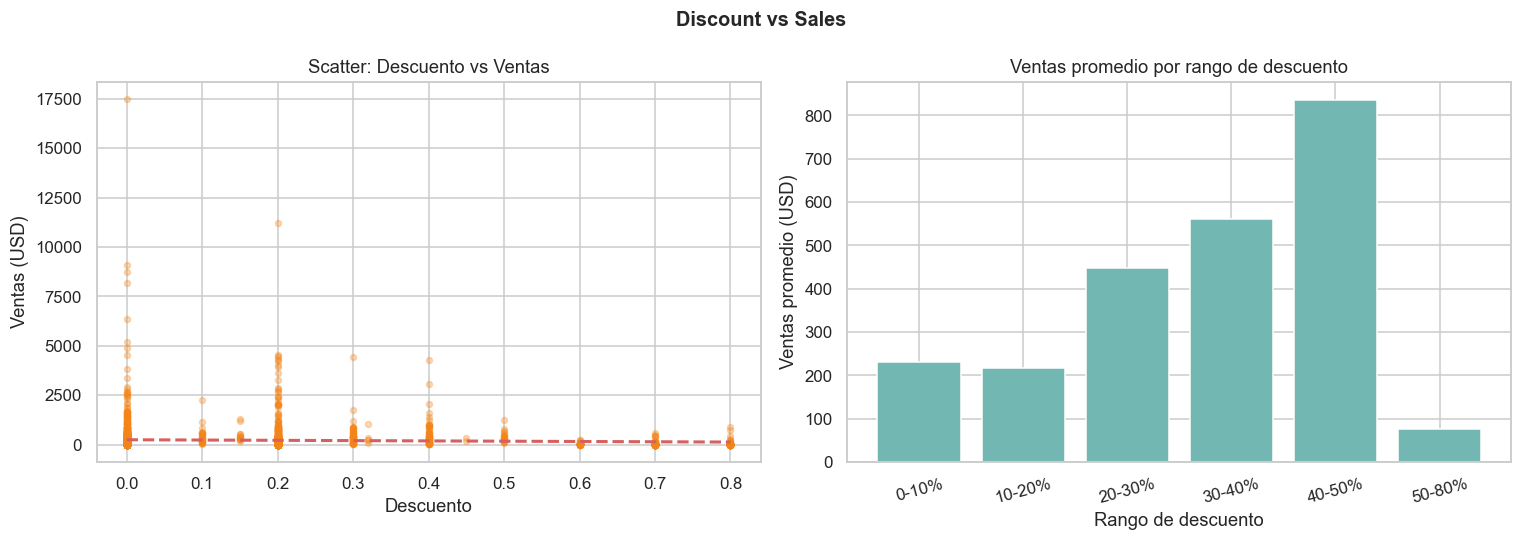

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Discount vs Sales', fontsize=13, fontweight='bold')

axes[0].scatter(sample['Discount'], sample['Sales'], alpha=0.3, s=15, color='#F58518')

# ✅ Drop NaNs together
sample_clean2 = sample[['Discount', 'Sales']].dropna()
z2 = np.polyfit(sample_clean2['Discount'], sample_clean2['Sales'], 1)
p2 = np.poly1d(z2)

axes[0].plot(x_line, p2(x_line), 'r--', linewidth=2)
axes[0].set_xlabel('Descuento')
axes[0].set_ylabel('Ventas (USD)')
axes[0].set_title('Scatter: Descuento vs Ventas')

sales_by_disc = df.groupby('discount_bin', observed=True)['Sales'].mean()
axes[1].bar(sales_by_disc.index, sales_by_disc.values, color='#72B7B2', edgecolor='white')
axes[1].set_title('Ventas promedio por rango de descuento')
axes[1].set_xlabel('Rango de descuento')
axes[1].set_ylabel('Ventas promedio (USD)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/eda_07_discount_vs_sales.png', bbox_inches='tight')
plt.show()

### Analisis por segmento de cliente — PENDIENTE

> **Nota:** Este analisis requiere los segmentos K-Means generados en la Fase 4
> (`03_segmentacion.ipynb`). Una vez ejecutado ese notebook, volver aqui y
> ejecutar la celda siguiente para completar el Bloque 2.3.
>
> Pregunta a responder: *¿El comportamiento del descuento varia entre segmentos?*
> Por ejemplo, ¿los clientes VIP son menos sensibles al descuento que los
> clientes en riesgo?


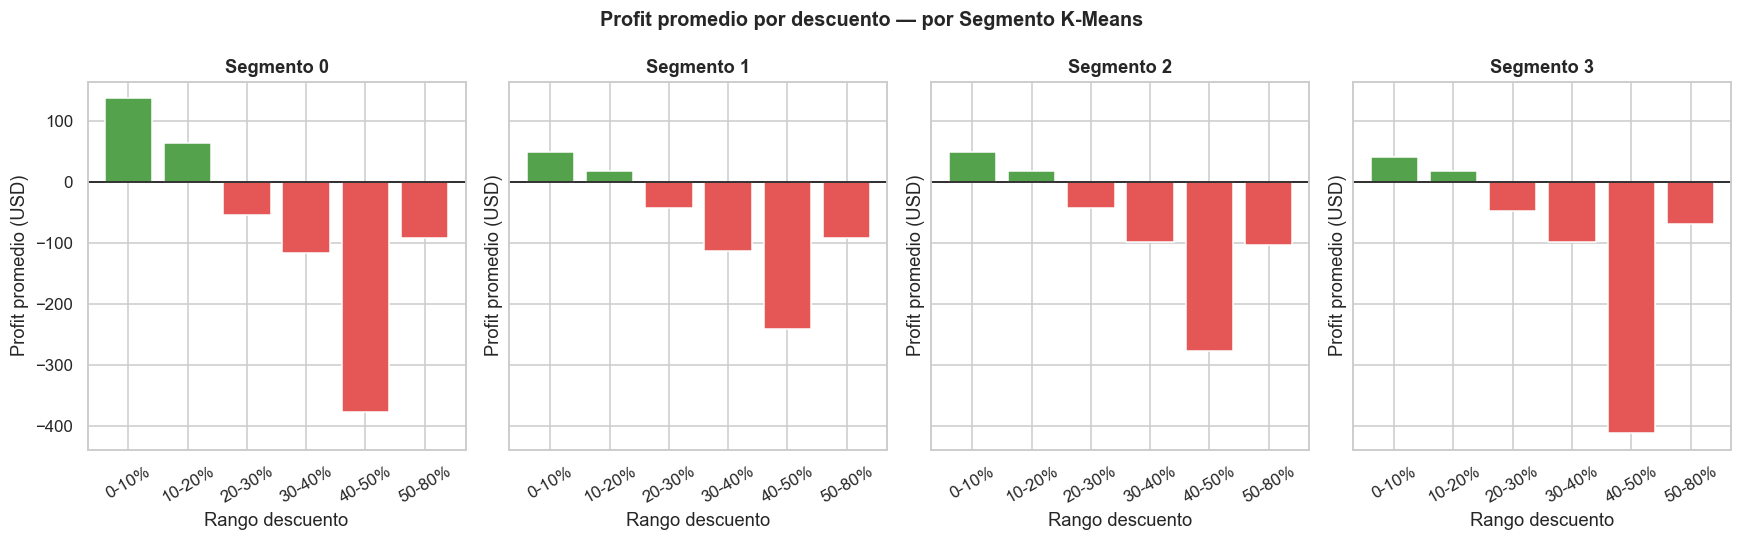

Grafica guardada: outputs/eda_17_discount_por_segmento.png


In [41]:
# PENDIENTE: ejecutar despues de 03_segmentacion.ipynb
# Este bloque asume que 'outputs/segmentos_clientes.csv' ya existe.

import os
SEG_PATH = "../outputs/segmentos_clientes.csv"

if not os.path.exists(SEG_PATH):
    print("Segmentos aun no disponibles. Ejecutar primero 03_segmentacion.ipynb.")
else:
    df_seg = pd.read_csv(SEG_PATH)
    df_with_seg = df.merge(df_seg, on='Customer_ID', how='left')

    fig, axes = plt.subplots(1, df_with_seg['segment'].nunique(), figsize=(16, 5), sharey=True)
    fig.suptitle('Profit promedio por descuento — por Segmento K-Means', fontsize=13, fontweight='bold')

    for ax, seg in zip(axes, sorted(df_with_seg['segment'].unique())):
        sub = df_with_seg[df_with_seg['segment'] == seg]
        profit_d = sub.groupby('discount_bin', observed=True)['Profit'].mean()
        colors_b = ['#54A24B' if v >= 0 else '#E45756' for v in profit_d.values]
        ax.bar(profit_d.index, profit_d.values, color=colors_b, edgecolor='white')
        ax.axhline(0, color='black', linewidth=1)
        ax.set_title(f'Segmento {seg}', fontweight='bold')
        ax.set_xlabel('Rango descuento')
        ax.set_ylabel('Profit promedio (USD)')
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig('../outputs/eda_17_discount_por_segmento.png', bbox_inches='tight')
    plt.show()
    print("Grafica guardada: outputs/eda_17_discount_por_segmento.png")


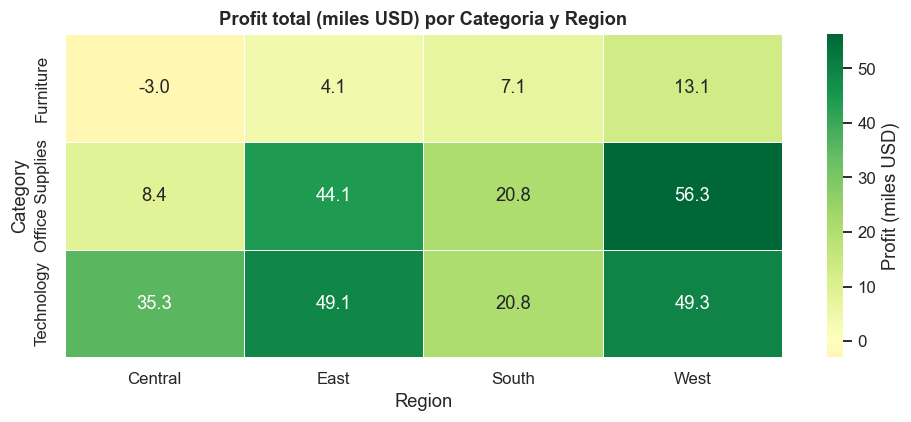

In [42]:
# ── Profit por Categoría y Region (heatmap)
pivot = df.pivot_table(values='Profit', index='Category', columns='Region', aggfunc='sum') / 1e3

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Profit (miles USD)'})
ax.set_title('Profit total (miles USD) por Categoria y Region', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_08_heatmap_profit.png', bbox_inches='tight')
plt.show()


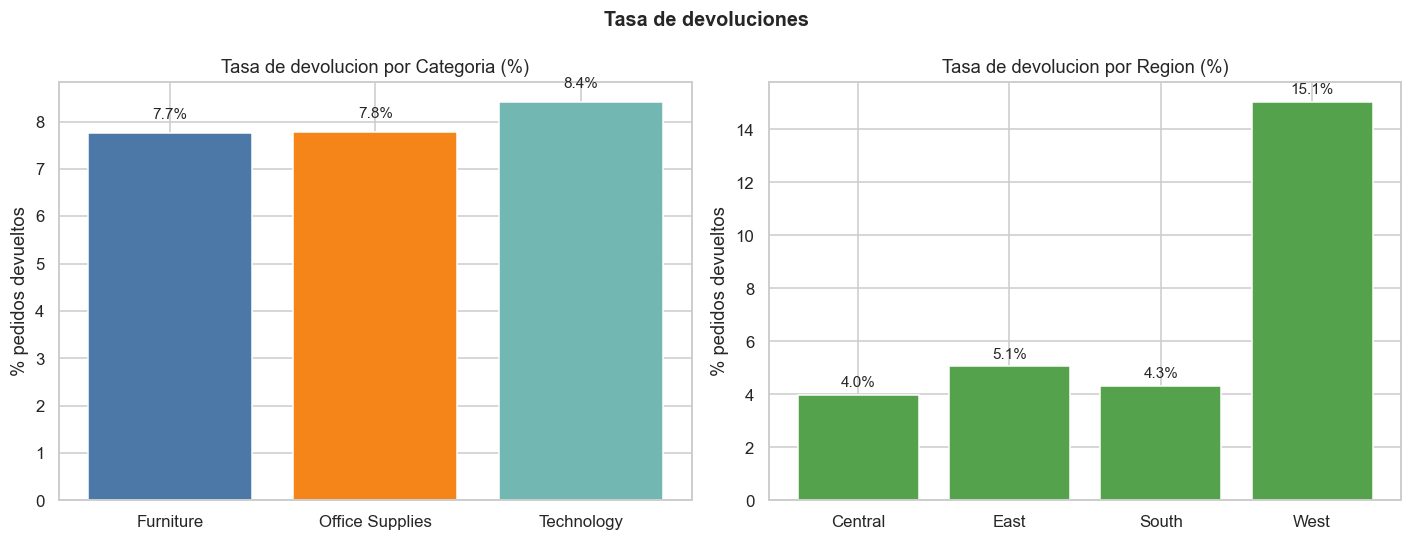

Tasa de devolucion global: 7.89%
Ordenes devueltas: 831 / 10,529


In [43]:
# ── Tasa de devoluciones por categoría y región
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tasa de devoluciones', fontsize=13, fontweight='bold')

ret_by_cat = df.groupby('Category')['is_returned'].mean() * 100
axes[0].bar(ret_by_cat.index, ret_by_cat.values, color=['#4C78A8','#F58518','#72B7B2'])
axes[0].set_title('Tasa de devolucion por Categoria (%)')
axes[0].set_ylabel('% pedidos devueltos')
for i, v in enumerate(ret_by_cat.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

ret_by_reg = df.groupby('Region')['is_returned'].mean() * 100
axes[1].bar(ret_by_reg.index, ret_by_reg.values, color='#54A24B')
axes[1].set_title('Tasa de devolucion por Region (%)')
axes[1].set_ylabel('% pedidos devueltos')
for i, v in enumerate(ret_by_reg.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/eda_09_devoluciones.png', bbox_inches='tight')
plt.show()

total_ret = df['is_returned'].mean() * 100
print(f"Tasa de devolucion global: {total_ret:.2f}%")
print(f"Ordenes devueltas: {df['is_returned'].sum():,} / {len(df):,}")


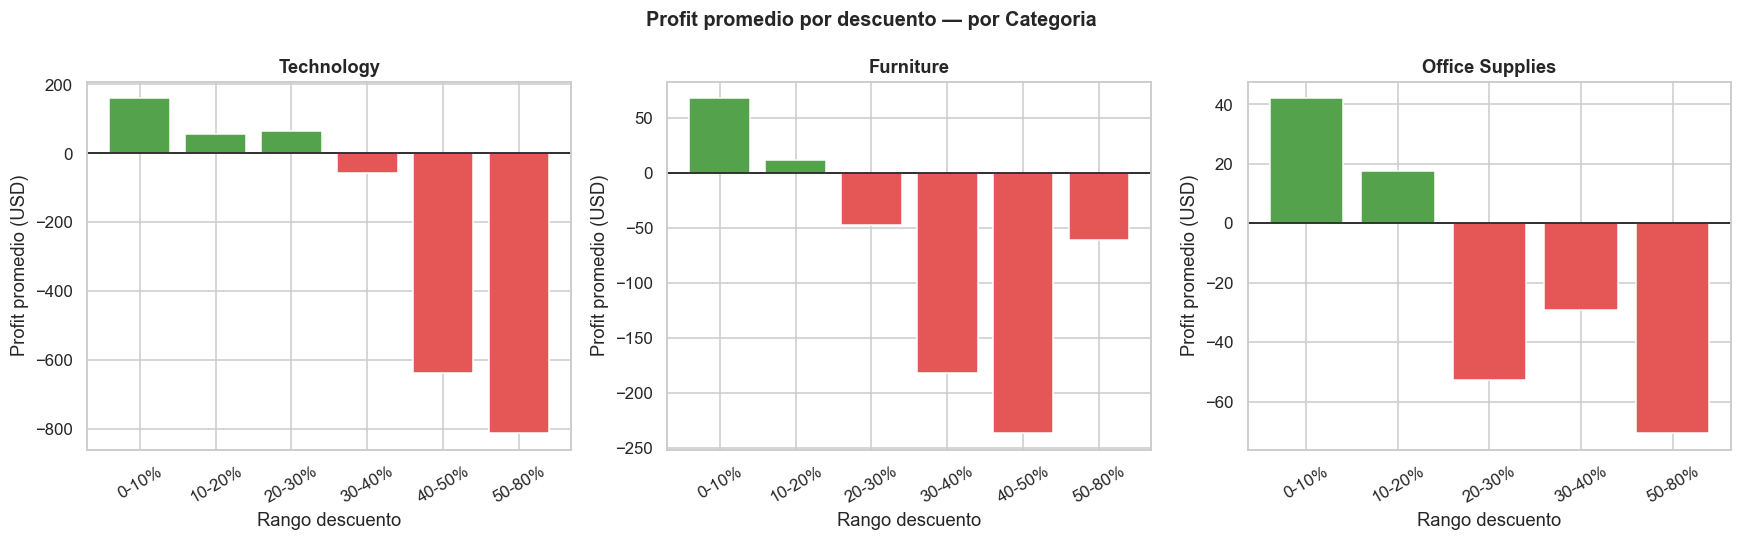

In [44]:
# ── Profit promedio por nivel de descuento y por categoría
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Profit promedio por descuento — por Categoria', fontsize=13, fontweight='bold')

for ax, cat, color in zip(axes, df['Category'].unique(), ['#4C78A8','#F58518','#72B7B2']):
    sub = df[df['Category'] == cat]
    profit_d = sub.groupby('discount_bin', observed=True)['Profit'].mean()
    colors_b = ['#54A24B' if v >= 0 else '#E45756' for v in profit_d.values]
    ax.bar(profit_d.index, profit_d.values, color=colors_b, edgecolor='white')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(cat, fontweight='bold')
    ax.set_xlabel('Rango descuento')
    ax.set_ylabel('Profit promedio (USD)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/eda_10_profit_descuento_categoria.png', bbox_inches='tight')
plt.show()


## Bloque 2.4 — Análisis temporal (2020–2023)

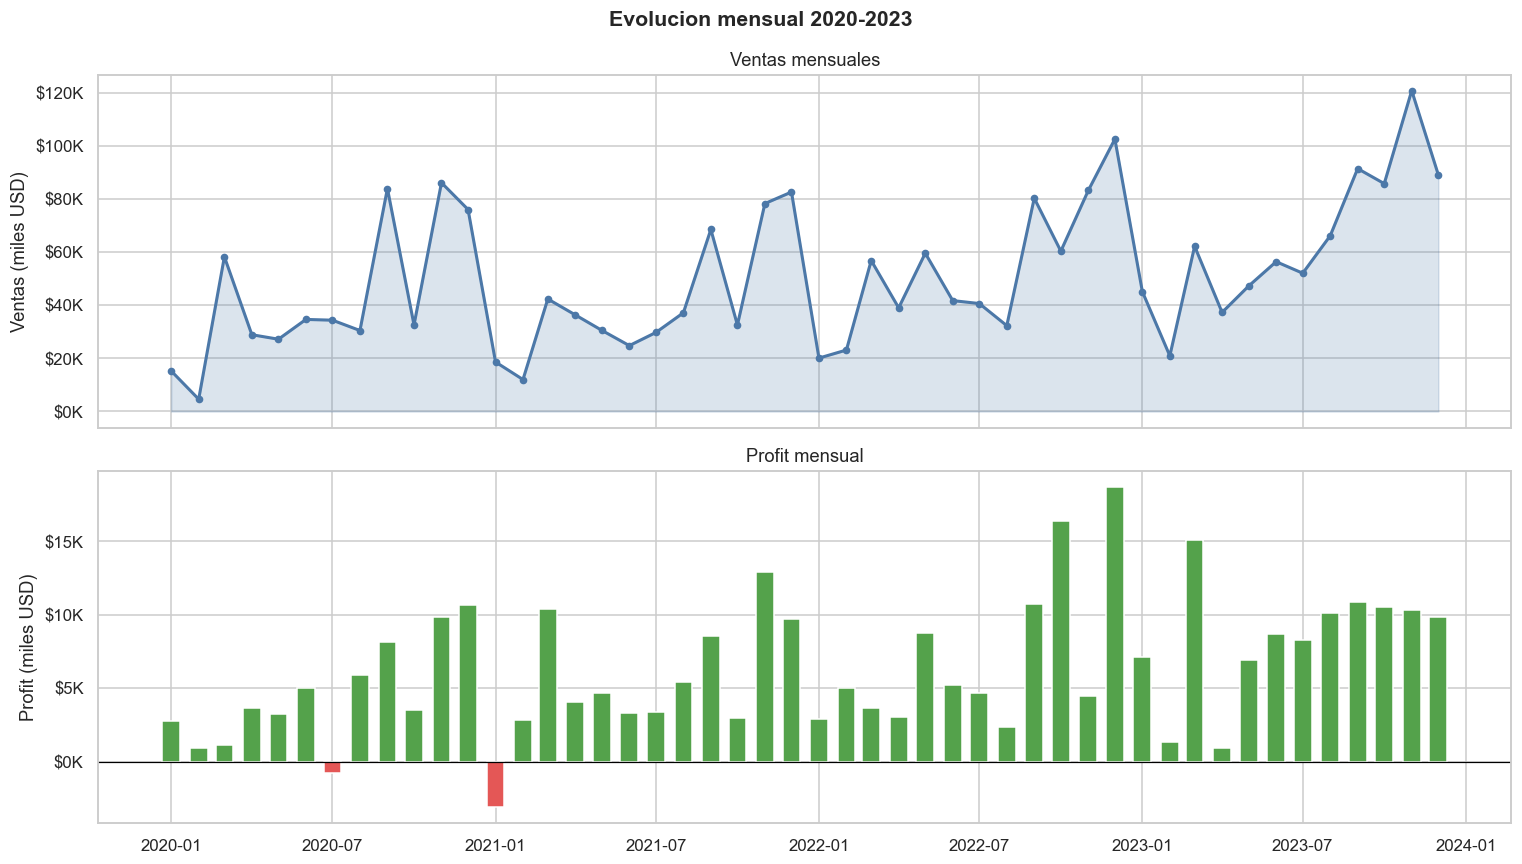

In [45]:
# ── Ventas y Profit mes a mes
monthly = (
    df.groupby(['year', 'month'])[['Sales', 'Profit']]
    .sum()
    .reset_index()
)
monthly['period'] = pd.to_datetime(monthly['year'].astype(str) + '-' + monthly['month'].astype(str) + '-01')
monthly = monthly.sort_values('period')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Evolucion mensual 2020-2023', fontsize=14, fontweight='bold')

axes[0].plot(monthly['period'], monthly['Sales'] / 1e3, color='#4C78A8', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(monthly['period'], monthly['Sales'] / 1e3, alpha=0.2, color='#4C78A8')
axes[0].set_ylabel('Ventas (miles USD)')
axes[0].set_title('Ventas mensuales')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

colors_profit = ['#54A24B' if v >= 0 else '#E45756' for v in monthly['Profit'].values]
axes[1].bar(monthly['period'], monthly['Profit'] / 1e3, color=colors_profit, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Profit (miles USD)')
axes[1].set_title('Profit mensual')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

plt.tight_layout()
plt.savefig('../outputs/eda_11_evolucion_mensual.png', bbox_inches='tight')
plt.show()


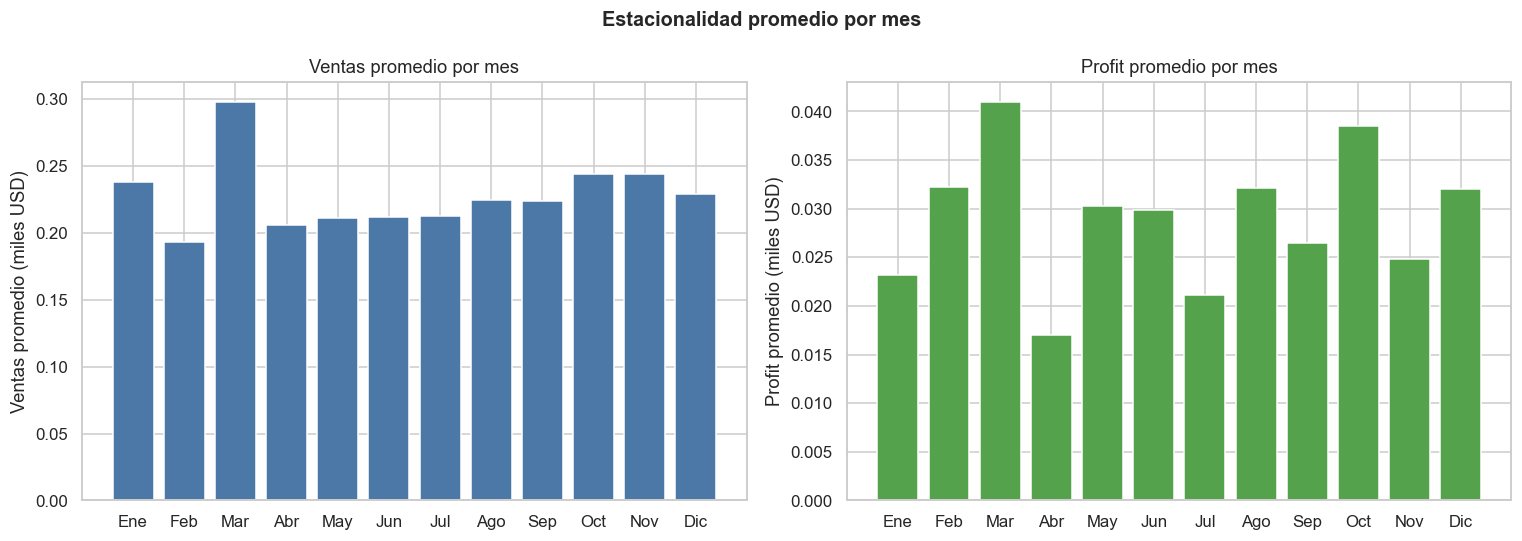

Meses con mayor venta promedio: ['Mar', 'Oct', 'Nov']


In [46]:
# ── Estacionalidad: ventas por mes del año (promedio sobre todos los años)
seasonal = df.groupby('month')[['Sales', 'Profit']].mean()
month_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Estacionalidad promedio por mes', fontsize=13, fontweight='bold')

axes[0].bar(range(1, 13), seasonal['Sales'] / 1e3, color='#4C78A8', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels)
axes[0].set_title('Ventas promedio por mes')
axes[0].set_ylabel('Ventas promedio (miles USD)')

colors_s = ['#54A24B' if v >= 0 else '#E45756' for v in seasonal['Profit'].values]
axes[1].bar(range(1, 13), seasonal['Profit'] / 1e3, color=colors_s, edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].set_title('Profit promedio por mes')
axes[1].set_ylabel('Profit promedio (miles USD)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../outputs/eda_12_estacionalidad.png', bbox_inches='tight')
plt.show()

# Meses con mayor volumen
top_months = seasonal['Sales'].nlargest(3).index.tolist()
print(f"Meses con mayor venta promedio: {[month_labels[m-1] for m in top_months]}")


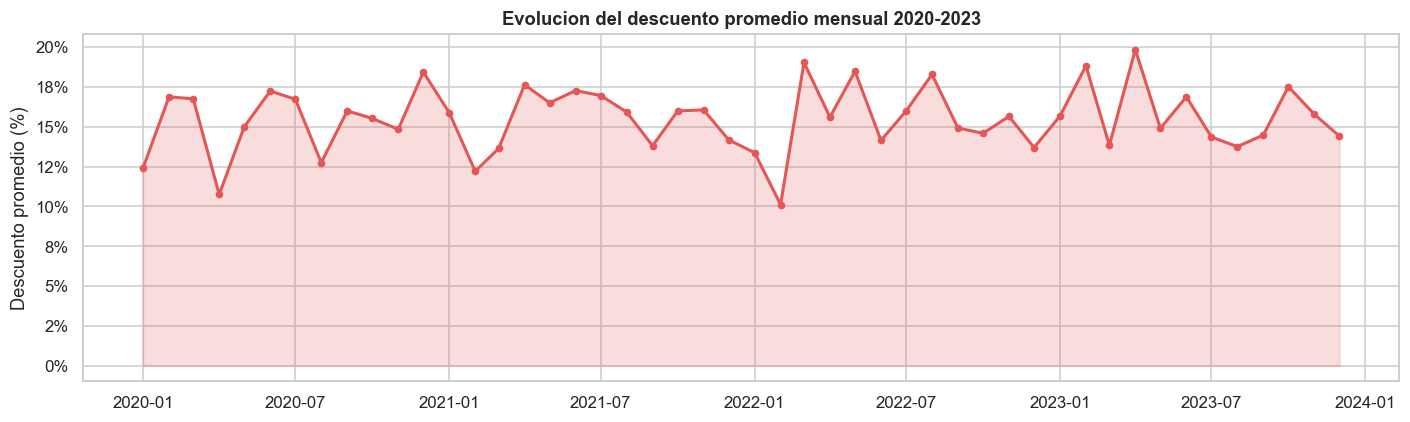

Descuento promedio global: 15.5%
% transacciones con descuento > 0: 51.7%


In [47]:
# ── Evolución del uso de descuentos en el tiempo
disc_trend = df.groupby(['year', 'month'])['Discount'].mean().reset_index()
disc_trend['period'] = pd.to_datetime(disc_trend['year'].astype(str) + '-' + disc_trend['month'].astype(str) + '-01')
disc_trend = disc_trend.sort_values('period')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(disc_trend['period'], disc_trend['Discount'] * 100, color='#E45756', linewidth=2, marker='o', markersize=4)
ax.fill_between(disc_trend['period'], disc_trend['Discount'] * 100, alpha=0.2, color='#E45756')
ax.set_title('Evolucion del descuento promedio mensual 2020-2023', fontweight='bold')
ax.set_ylabel('Descuento promedio (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('../outputs/eda_13_evolucion_descuentos.png', bbox_inches='tight')
plt.show()

print(f"Descuento promedio global: {df['Discount'].mean()*100:.1f}%")
print(f"% transacciones con descuento > 0: {(df['Discount'] > 0).mean()*100:.1f}%")


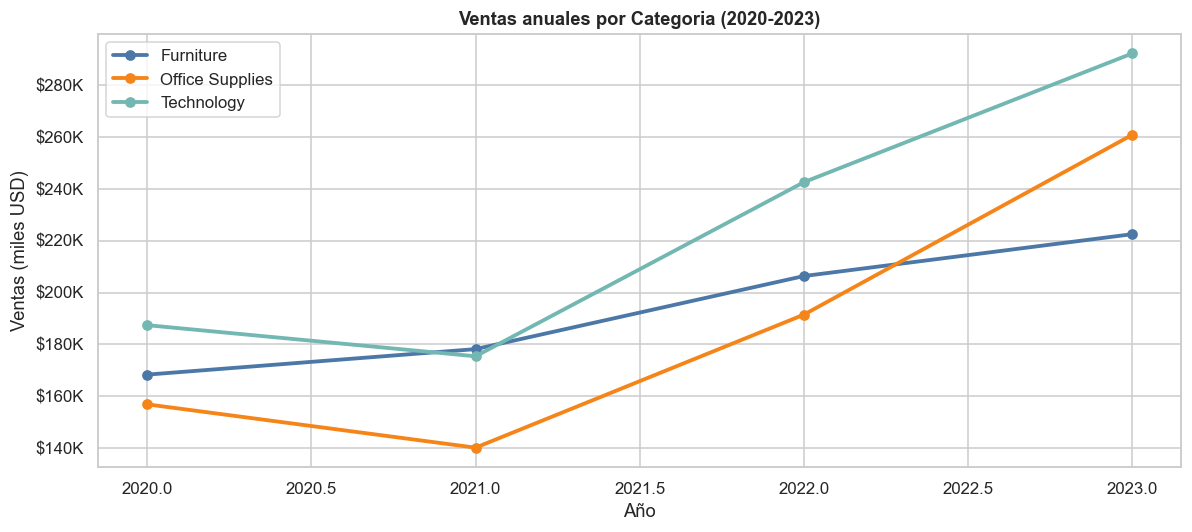

In [48]:
# ── Ventas anuales por categoría (YoY)
yoy = df.groupby(['year', 'Category'])['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
colors_cat = {'Furniture': '#4C78A8', 'Office Supplies': '#F58518', 'Technology': '#72B7B2'}
for cat in yoy['Category'].unique():
    sub = yoy[yoy['Category'] == cat]
    ax.plot(sub['year'], sub['Sales'] / 1e3, marker='o', linewidth=2.5,
            label=cat, color=colors_cat.get(cat, 'gray'))

ax.set_title('Ventas anuales por Categoria (2020-2023)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Ventas (miles USD)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
plt.tight_layout()
plt.savefig('../outputs/eda_14_yoy_categorias.png', bbox_inches='tight')
plt.show()


## Bloque 2.5 — Detección de outliers (método IQR)

Identificar valores extremos y documentar la decisión de tratamiento.

In [49]:
def iqr_outliers(series, name):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    pct = len(outliers) / len(series) * 100
    print(f"  {name:<18}: {len(outliers):>5,} outliers ({pct:.1f}%)  "
          f"[{lower:.2f}, {upper:.2f}]  min={series.min():.2f}  max={series.max():.2f}")
    return lower, upper, outliers

print("Outliers por columna (metodo IQR, factor 1.5):")
print("-" * 80)
bounds = {}
for col in ['Sales', 'Profit', 'Discount', 'Quantity']:
    lo, hi, outs = iqr_outliers(df[col].dropna(), col)
    bounds[col] = (lo, hi)


Outliers por columna (metodo IQR, factor 1.5):
--------------------------------------------------------------------------------
  Sales             : 1,225 outliers (11.6%)  [-271.91, 499.77]  min=0.44  max=22638.48
  Profit            : 1,970 outliers (18.7%)  [-40.44, 72.18]  min=-6599.98  max=8399.98
  Discount          :   899 outliers (8.5%)  [-0.30, 0.50]  min=0.00  max=0.80
  Quantity          :   182 outliers (1.7%)  [-2.50, 9.50]  min=1.00  max=14.00


In [50]:
# Decision documentada sobre tratamiento de extremos
print(f'''
DECISION SOBRE VALORES EXTREMOS
================================
Percentil optimo identificado: p{P_OPT} (Sales <= ${CAP_SALES:,.2f})
Criterio: mean/median <= 15% de diferencia en el segmento principal.

Dataset principal (df_viz): {len(df_viz):,} registros ({len(df_viz)/len(df)*100:.1f}%)
  -> Histogramas, boxplots y analisis descriptivo
  -> Media y mediana dentro de rango aceptable

Segmento premium (df_premium): {len(df_premium):,} registros ({len(df_premium)/len(df)*100:.1f}%)
  -> Sales > ${CAP_SALES:,.2f} (por encima de p{P_OPT})
  -> Analizado por separado en Bloque 2.7
  -> Hipotesis: clientes de alto valor / transacciones corporativas

df original: preservado sin modificar (traceabilidad).
Discount y Quantity: sin cortes, rangos coherentes con el negocio.
''')


DECISION SOBRE VALORES EXTREMOS
Percentil optimo identificado: p85 (Sales <= $388.70)
Criterio: mean/median <= 15% de diferencia en el segmento principal.

Dataset principal (df_viz): 8,950 registros (85.0%)
  -> Histogramas, boxplots y analisis descriptivo
  -> Media y mediana dentro de rango aceptable

Segmento premium (df_premium): 1,579 registros (15.0%)
  -> Sales > $388.70 (por encima de p85)
  -> Analizado por separado en Bloque 2.7
  -> Hipotesis: clientes de alto valor / transacciones corporativas

df original: preservado sin modificar (traceabilidad).
Discount y Quantity: sin cortes, rangos coherentes con el negocio.



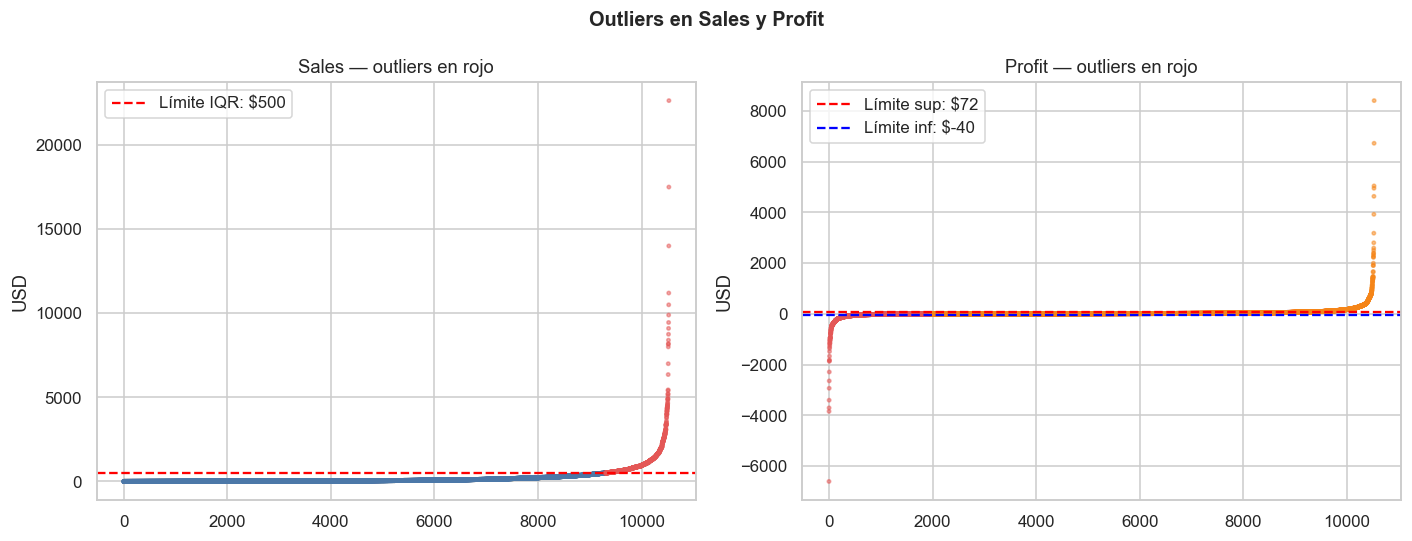

In [51]:
# ── Visualización de outliers en Sales y Profit
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Outliers en Sales y Profit', fontsize=13, fontweight='bold')

# Sales
lo_s, hi_s = bounds['Sales']
colors_s = ['#E45756' if (v < lo_s or v > hi_s) else '#4C78A8' for v in df['Sales']]
axes[0].scatter(range(len(df)), df['Sales'].sort_values().values, c=sorted(colors_s), s=5, alpha=0.5)
axes[0].axhline(hi_s, color='red', linestyle='--', linewidth=1.5, label=f'Límite IQR: ${hi_s:,.0f}')
axes[0].set_title('Sales — outliers en rojo')
axes[0].set_ylabel('USD')
axes[0].legend()

# Profit
lo_p, hi_p = bounds['Profit']
colors_p = ['#E45756' if (v < lo_p or v > hi_p) else '#F58518' for v in df['Profit']]
axes[1].scatter(range(len(df)), df['Profit'].sort_values().values, c=sorted(colors_p), s=5, alpha=0.5)
axes[1].axhline(hi_p, color='red', linestyle='--', linewidth=1.5, label=f'Límite sup: ${hi_p:,.0f}')
axes[1].axhline(lo_p, color='blue', linestyle='--', linewidth=1.5, label=f'Límite inf: ${lo_p:,.0f}')
axes[1].set_title('Profit — outliers en rojo')
axes[1].set_ylabel('USD')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/eda_15_outliers.png', bbox_inches='tight')
plt.show()


## Bloque 2.7 — Analisis del segmento premium

Las transacciones por encima del percentil optimo se analizan de forma separada.
Hipotesis: representan clientes corporativos o de alto valor cuyo comportamiento
difiere del cliente tipico. Se evalua margen, categoria, region y patron de descuentos.

In [52]:
# Bloque 2.7 — Analisis del segmento premium
# Transacciones con Sales > umbral del percentil optimo

print('=' * 60)
print(f'SEGMENTO PREMIUM — Sales > ${CAP_SALES:,.2f} (p{P_OPT})')
print('=' * 60)
print(f'Transacciones  : {len(df_premium):,}')
print(f'% del total    : {len(df_premium)/len(df)*100:.1f}%')
print(f'Clientes unicos: {df_premium["Customer_ID"].nunique()}')
print(f'Sales total    : ${df_premium["Sales"].sum():,.0f}  ({df_premium["Sales"].sum()/df["Sales"].sum()*100:.1f}% del revenue total)')
print(f'Profit total   : ${df_premium["Profit"].sum():,.0f}  ({df_premium["Profit"].sum()/df["Profit"].sum()*100:.1f}% del profit total)')
pm_prem = df_premium['Profit'].sum() / df_premium['Sales'].sum() * 100
pm_viz  = df_viz['Profit'].sum()     / df_viz['Sales'].sum()     * 100
print(f'Profit margin  : {pm_prem:.1f}% vs {pm_viz:.1f}% en segmento principal')

print('\nDistribucion por Categoria:')
cat_cnt = df_premium['Category'].value_counts()
for cat, n in cat_cnt.items():
    print(f'  {cat:<20} {n:>5}  ({n/len(df_premium)*100:.1f}%)')

print('\nDistribucion por Region:')
reg_cnt = df_premium['Region'].value_counts()
for reg, n in reg_cnt.items():
    print(f'  {reg:<20} {n:>5}  ({n/len(df_premium)*100:.1f}%)')

# Columna Sub-Category (nombre con guion en la DB)
sub_col = 'Sub-Category'
print(f'\nTop 10 Sub-Categorias por Sales en segmento premium:')
top_sub = (df_premium.groupby(sub_col)['Sales']
           .agg(total_sales='sum', n_transacciones='count', promedio='mean')
           .sort_values('total_sales', ascending=False).head(10))
top_sub['total_sales'] = top_sub['total_sales'].map('${:,.0f}'.format)
top_sub['promedio']    = top_sub['promedio'].map('${:,.0f}'.format)
print(top_sub.to_string())

print('\nTop 10 clientes premium (mayor Sales acumulado):')
top_cli = (df_premium.groupby('Customer_ID')
    .agg(n_transac=('Sales','count'),
         sales_total=('Sales','sum'),
         profit_total=('Profit','sum'),
         avg_discount=('Discount','mean'))
    .sort_values('sales_total', ascending=False).head(10))
top_cli['margin_%'] = (top_cli['profit_total'] / top_cli['sales_total'] * 100).round(1)
top_cli['sales_total']  = top_cli['sales_total'].map('${:,.0f}'.format)
top_cli['profit_total'] = top_cli['profit_total'].map('${:,.0f}'.format)
top_cli['avg_discount'] = top_cli['avg_discount'].map('{:.1%}'.format)
print(top_cli.to_string())

SEGMENTO PREMIUM — Sales > $388.70 (p85)
Transacciones : 1,579
% del total   : 15.0%
Clientes unicos: 634
Sales total   : $1,709,564 (70.6% del revenue total)
Profit total  : $213,502 (69.9% del profit total)
Profit margin : 12.5% vs 12.9% en segmento principal

Distribucion por Categoria:
                 count     pct
Category                      
Furniture          602 38.1000
Technology         575 36.4000
Office Supplies    402 25.5000

Distribucion por Region:
         count     pct
Region                
West       528 33.4000
East       459 29.1000
Central    339 21.5000
South      253 16.0000

Top 10 Sub-Categorias por Sales en segmento premium:


KeyError: 'Sub_Category'

In [ ]:
# Visualizacion: segmento premium vs segmento principal
sub_col = 'Sub-Category'
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Segmento Premium (p{P_OPT}) vs Segmento Principal', fontsize=13, fontweight='bold')

# 1. Distribucion de Sales superpuesta
ax = axes[0]
ax.hist(df_viz['Sales'].dropna(),     bins=40, alpha=0.7, color='#4C78A8', label=f'Principal (n={len(df_viz):,})')
ax.hist(df_premium['Sales'].dropna(), bins=20, alpha=0.7, color='#E45756', label=f'Premium (n={len(df_premium):,})')
ax.set_title('Distribucion Sales', fontweight='bold')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)

# 2. Profit margin por categoria
ax = axes[1]
cats = ['Furniture', 'Office Supplies', 'Technology']
x = range(len(cats))
def margin(dframe, cat):
    sub = dframe[dframe['Category'] == cat]
    s = sub['Sales'].sum()
    return sub['Profit'].sum() / s * 100 if s > 0 else 0
m_viz  = [margin(df_viz,     c) for c in cats]
m_prem = [margin(df_premium, c) for c in cats]
w = 0.35
ax.bar([i - w/2 for i in x], m_viz,  w, label='Principal', color='#4C78A8', alpha=0.8)
ax.bar([i + w/2 for i in x], m_prem, w, label='Premium',   color='#E45756', alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(cats, fontsize=9)
ax.set_title('Profit Margin % por Categoria', fontweight='bold')
ax.set_ylabel('Margin %')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(fontsize=9)

# 3. Distribucion de descuentos
ax = axes[2]
ax.hist(df_viz['Discount'].dropna(),     bins=15, alpha=0.7, color='#4C78A8', label='Principal', density=True)
ax.hist(df_premium['Discount'].dropna(), bins=10, alpha=0.7, color='#E45756', label='Premium',   density=True)
ax.set_title('Distribucion Descuentos', fontweight='bold')
ax.set_xlabel('Descuento')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/eda_07_premium_vs_principal.png', bbox_inches='tight')
plt.show()

print('\nCONCLUSION SEGMENTO PREMIUM:')
pm_viz  = df_viz['Profit'].sum()     / df_viz['Sales'].sum()     * 100
pm_prem = df_premium['Profit'].sum() / df_premium['Sales'].sum() * 100
rep_rev = df_premium['Sales'].sum()  / df['Sales'].sum()         * 100
rep_cli = df_premium['Customer_ID'].nunique() / df['Customer_ID'].nunique() * 100
print(f'  - {rep_cli:.1f}% de los clientes generan {rep_rev:.1f}% del revenue')
print(f'  - Margin premium: {pm_prem:.1f}% vs {pm_viz:.1f}% en segmento principal')
if pm_prem > pm_viz:
    print('  - Margen MAYOR en premium: transacciones de alto valor son mas rentables.')
else:
    print('  - Margen MENOR en premium: descuentos agresivos en ventas grandes reducen la rentabilidad.')

## Bloque 2.6 — Matriz de correlación completa

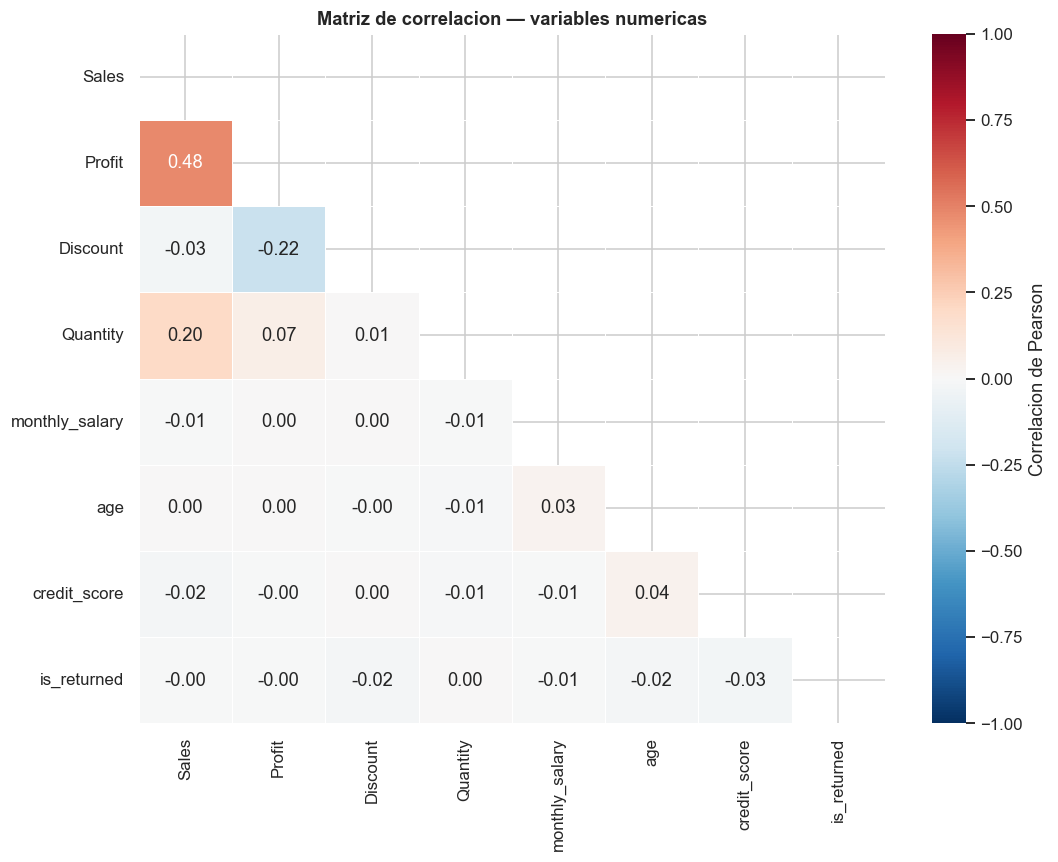

Top correlaciones con Profit:
Sales             0.4809
Discount         -0.2228
Quantity          0.0674
credit_score     -0.0027
monthly_salary    0.0006
age               0.0004
is_returned      -0.0002


In [ ]:
# Correlación entre todas las variables numéricas del JOIN
cols_corr = ['Sales', 'Profit', 'Discount', 'Quantity',
             'monthly_salary', 'age', 'credit_score', 'is_returned']
corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Correlacion de Pearson'})
ax.set_title('Matriz de correlacion — variables numericas', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_16_correlacion.png', bbox_inches='tight')
plt.show()

print("Top correlaciones con Profit:")
print(corr_matrix['Profit'].drop('Profit').sort_values(key=abs, ascending=False).to_string())


## Hallazgos consolidados y recomendaciones

### Hallazgos clave del EDA

**Rentabilidad:**
- Las sub-categorías **Tables** y **Bookcases** tienen profit negativo — son candidatas a revisar política de precios/descuentos.
- Descuentos superiores al **20%** muestran correlación negativa fuerte con el profit — confirma hipótesis del modelo ML.
- La relación **Discount → Profit** varía por categoría, lo que justifica un modelo por segmento.

**Ventas:**
- **Technology** tiene el mayor volumen de ventas pero con alta dispersión en profit.
- La región **West** lidera en ventas; **South** tiene menor volumen relativo.
- Pico estacional claro en **Q4** (Octubre–Diciembre) — comportamiento de fin de año.

**Devoluciones:**
- Tasa de devolución global entre 5–10% — impacto no despreciable en revenue.
- Categoría con mayor tasa: analizar en la siguiente celda.

**Variables socioeconómicas:**
- Las variables de Customer (`monthly_salary`, `credit_score`, `age`) tienen baja correlación directa con `Profit` individual — su valor está en la **segmentación** (Fase 3), no en predicción lineal.

### Recomendaciones de negocio
1. **Establecer tope de descuento del 20%** como política inicial — por encima la rentabilidad cae sistemáticamente.
2. **Revisar línea de Furniture** — Tables y Bookcases operan en pérdida; posible problema de pricing.
3. **Anticipar demanda Q4** con inventario adicional en Technology y Office Supplies.
4. **Programa de reducción de devoluciones** focalizando en las subcategorías con mayor tasa.


In [ ]:
# Guardar el DataFrame de trabajo para reusarlo en notebooks posteriores
df_work = df.copy()

# Exportar lista de archivos de gráficas generados
import os
graficas = [f for f in os.listdir('../outputs') if f.startswith('eda_')]
print(f"Graficas generadas: {len(graficas)}")
for g in sorted(graficas):
    print(f"  outputs/{g}")

print("\nEDA completado. Tabla de trabajo lista para Fase 3 (Feature Engineering).")
print(f"Forma tabla de trabajo: {df_work.shape}")


Graficas generadas: 17
  outputs/eda_01_distribuciones_numericas.png
  outputs/eda_02_boxplots.png
  outputs/eda_03_categoricas.png
  outputs/eda_04_subcategorias.png
  outputs/eda_05_socioeconomicas.png
  outputs/eda_06_discount_vs_profit.png
  outputs/eda_07_discount_vs_sales.png
  outputs/eda_08_heatmap_profit.png
  outputs/eda_09_devoluciones.png
  outputs/eda_10_profit_descuento_categoria.png
  outputs/eda_11_evolucion_mensual.png
  outputs/eda_12_estacionalidad.png
  outputs/eda_13_evolucion_descuentos.png
  outputs/eda_14_yoy_categorias.png
  outputs/eda_15_outliers.png
  outputs/eda_16_correlacion.png
  outputs/eda_17_discount_por_segmento.png

EDA completado. Tabla de trabajo lista para Fase 3 (Feature Engineering).
Forma tabla de trabajo: (21056, 29)
